In [1]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pyfar as pf
from FastBEMT.JobParameters import LowFidelityParameters
from FastBEMT.Propeller import Propeller
from FastBEMT.BPM import BPM

In [2]:
def load_data(filepath):
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    t = data['sound']['channels']['1']['time']
    p = data['sound']['channels']['1']['pressure']
    fs = 1.0 / np.mean(np.diff(t))
    return t, p, fs

# Paths
measurements_dir = '../Datasets/Measurements'
background_dir = '../Datasets/Background'
prop_geom_dir = '../Datasets/Propellers'

In [3]:
def get_a_weighting(f):
    """Calculate A-weighting offset in dB for a given frequency f."""
    ra = lambda f: (12194**2 * f**4) / (
        (f**2 + 20.6**2) * np.sqrt((f**2 + 107.7**2) * (f**2 + 737.9**2)) * (f**2 + 12194**2)
    )
    return 20 * np.log10(ra(f)) - 20 * np.log10(ra(1000))

def calc_oaspl(spl_array, freqs, weighted=False):
    """Calculates OSPL or A-weighted OASPL."""
    valid_mask = np.isfinite(spl_array)
    spl = spl_array[valid_mask]
    f = freqs[valid_mask]
    
    if len(spl) == 0: return 0
    
    if weighted:
        a_offsets = get_a_weighting(f)
        spl = spl + a_offsets
        
    return 10 * np.log10(np.sum(10**(spl[f >= 100] / 10)))

In [4]:
# 1. Map Background files by (Date, RPM)
bg_map = {}
for bg_path in glob.glob(os.path.join(background_dir, "Background_*.pkl")):
    name = os.path.basename(bg_path).replace('.pkl', '')
    parts = name.split('_')
    date_key = "-".join(parts[1].split('-')[:3]) # YYYY-MM-DD
    rpm_key = parts[3]
    bg_map[(date_key, rpm_key)] = bg_path

# 2. Group Measurements by Model and RPM
groups = {}
prop_files = glob.glob(os.path.join(measurements_dir, "*.pkl"))
for f_path in prop_files:
    name = os.path.basename(f_path).replace('.pkl', '')
    parts = name.split('_')
    model, date_full, rpm = parts[0], parts[1], parts[3]
    
    if model not in groups: groups[model] = {}
    if rpm not in groups[model]: groups[model][rpm] = []
    groups[model][rpm].append({'path': f_path, 'date': "-".join(date_full.split('-')[:3])})

results_summary = []

# 3. Process each Model/RPM combination
for model, rpms in groups.items():
    # Load Geometry once for this model
    geom_path = os.path.join(prop_geom_dir, f"{model}.pkl")
    if not os.path.exists(geom_path):
        print(f"Skipping {model}: No geometry file found.")
        continue
        
    with open(geom_path, "rb") as f:
        blade_dict = pickle.load(f)

    for rpm_val_str, measurements in rpms.items():
        rpm_val = float(rpm_val_str)
        print(f"\n--- Processing {model} at {rpm_val} RPM ---")

        # --- RUN SIMULATION (Once per Model/RPM) ---
        params = LowFidelityParameters(
            rpm=rpm_val,
            a_inf=343,
            rho=1.225,
            mu=1.81e-5,
            n_blades=blade_dict['n_blades'],
            p_ref=2e-5,
            revolutions=5,
            num_obs_times_per_rev=50,
        )

        propeller = Propeller(
            propeller_geometry=blade_dict,
            params=params,
        )
        
        propeller.run_bemt(v_inf=0)
        r_observer = np.array([[0.1, 1.8, 0], [0.1, 1.8, 0]])
        propeller.run_compact_f1a(observer_positions=r_observer, use_gpu=True)

        third_octave_freqs = pf.dsp.filter.fractional_octave_frequencies(num_fractions=3, frequency_range=(20,20000))[0]
        bpm = BPM(propeller=propeller, frequencies=third_octave_freqs)
        bpm.run_bpm()

        t = propeller.t[:, 0]
        p_f1a = propeller.p_tot[:, 0]

        f1a_spl_3oct = []
        n_o = propeller.spl.shape[1]
        for fc in third_octave_freqs:
            f_low, f_high = fc / (2 ** (1 / 6)), fc * (2 ** (1 / 6))
            mask = (propeller.freq[:, 0] >= f_low) & (propeller.freq[:, 0] < f_high)
            if np.any(mask):
                p_band = np.sum(10 ** (propeller.spl[mask, :] / 10), axis=0)
                f1a_spl_3oct.append(10 * np.log10(p_band))
            else:
                f1a_spl_3oct.append(np.full(n_o, -np.inf))
        f1a_spl_3oct = np.array(f1a_spl_3oct)

        L_total = 10 * np.log10(
            10 ** (f1a_spl_3oct / 10) # ok
            + 10 ** (bpm.spl_lbl / 10) # ok
            + 10 ** (bpm.spl_tbl / 10)
            + 10 ** (bpm.spl_teb / 10)
            + 10 ** (bpm.spl_ti / 10)
            + 10 ** (bpm.spl_tip / 10) # ok
        )
        ospl_f1a_steady_state = calc_oaspl(f1a_spl_3oct[:, 0], third_octave_freqs, weighted=False)
        oaspl_f1a_steady_state = calc_oaspl(f1a_spl_3oct[:, 0], third_octave_freqs, weighted=True)

        ospl_tot_steady_state = calc_oaspl(L_total[:, 0], third_octave_freqs, weighted=False)
        oaspl_tot_steady_state = calc_oaspl(L_total[:, 0], third_octave_freqs, weighted=True)

        ################################################
        exp_ospls_for_this_case = []

        # --- PROCESS CORRESPONDING MEASUREMENTS ---
        for entry in measurements:
            t, p, fs_total = load_data(entry['path'])
            signal = pf.Signal(p, fs_total, fft_norm='rms')
            meas_frequencies = signal.frequencies
            meas_spl = pf.dsp.decibel(signal, domain='freq', log_reference=propeller.params.p_ref).squeeze()

            exp_spl_3oct = []
            for fc in third_octave_freqs:
                f_low, f_high = fc / (2**(1/6)), fc * (2**(1/6))
                mask = (meas_frequencies >= f_low) & (meas_frequencies < f_high)
                if np.any(mask):
                    P_band = np.sum(10**(meas_spl[mask] / 10))
                    exp_spl_3oct.append(10 * np.log10(P_band))
                else:
                    exp_spl_3oct.append(-np.inf)

            exp_spl_3oct = np.array(exp_spl_3oct)

            ospl_exp = calc_oaspl(exp_spl_3oct, third_octave_freqs, weighted=False)
            oaspl_exp = calc_oaspl(exp_spl_3oct, third_octave_freqs, weighted=True)

            exp_ospls_for_this_case.append(ospl_exp)
            
            bg_key = (entry['date'], rpm_val_str)
            if bg_key in bg_map:
                t_bg, p_bg, fs_bg = load_data(bg_map[bg_key])
                print(f"  -> Analyzed {os.path.basename(entry['path'])} with noise floor.")

            else:
                print(f"  -> Warning: No background file for date {entry['date']} at {rpm_val_str} RPM")

        avg_ospl_exp = np.mean(exp_ospls_for_this_case)
        std_ospl_exp = np.std(exp_ospls_for_this_case)
        results_summary.append({
                'Model': model,
                'RPM': rpm_val,
                'OSPL_F1A (Steady State)': round(ospl_f1a_steady_state, 2),
                'OSPL_Total (Steady State)': round(ospl_tot_steady_state, 2),
                'OSPL_Exp (Avg)': round(avg_ospl_exp, 2),
                'OSPL_Exp (Std)': round(std_ospl_exp, 2),
            })
    


--- Processing 10x5e at 3000.0 RPM ---
  -> Analyzed 10x5e_2024-11-28-11-23-21_RPM_3000.pkl with noise floor.
  -> Analyzed 10x5e_2024-11-28-11-29-37_RPM_3000.pkl with noise floor.
  -> Analyzed 10x5e_2024-11-28-11-48-50_RPM_3000.pkl with noise floor.

--- Processing 10x5e at 3500.0 RPM ---
  -> Analyzed 10x5e_2024-11-28-11-23-21_RPM_3500.pkl with noise floor.
  -> Analyzed 10x5e_2024-11-28-11-29-37_RPM_3500.pkl with noise floor.
  -> Analyzed 10x5e_2024-11-28-11-48-50_RPM_3500.pkl with noise floor.

--- Processing 10x5e at 4000.0 RPM ---
  -> Analyzed 10x5e_2024-11-28-11-23-21_RPM_4000.pkl with noise floor.
  -> Analyzed 10x5e_2024-11-28-11-29-37_RPM_4000.pkl with noise floor.
  -> Analyzed 10x5e_2024-11-28-11-48-50_RPM_4000.pkl with noise floor.

--- Processing 10x5e at 4500.0 RPM ---
  -> Analyzed 10x5e_2024-11-28-11-23-21_RPM_4500.pkl with noise floor.
  -> Analyzed 10x5e_2024-11-28-11-29-37_RPM_4500.pkl with noise floor.
  -> Analyzed 10x5e_2024-11-28-11-48-50_RPM_4500.pkl with n

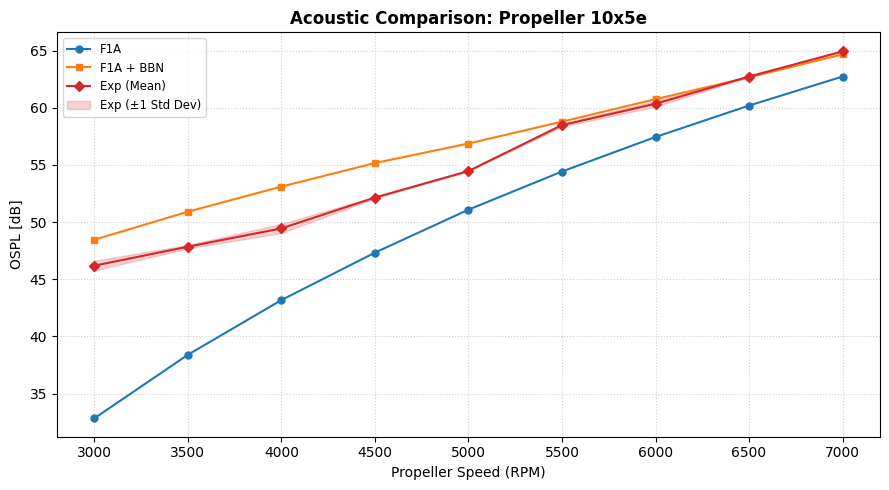

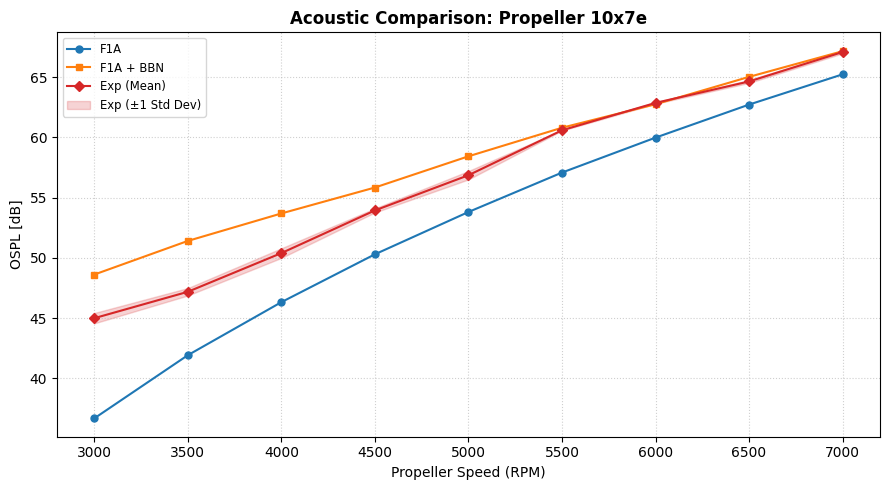

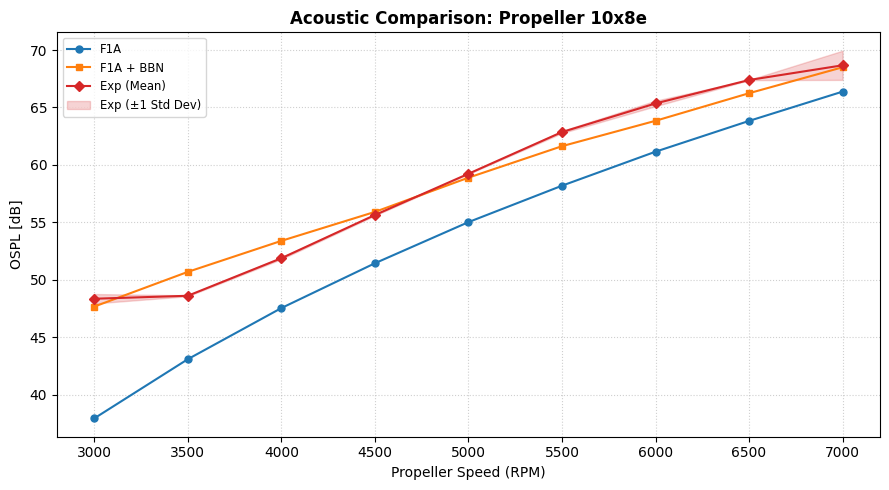

In [5]:
# 1. Convert your list of dictionaries to a DataFrame
df = pd.DataFrame(results_summary)

# 2. Get unique models
models = df['Model'].unique()

for model in models:
    # Filter data for the specific propeller model
    subset = df[df['Model'] == model].sort_values('RPM')
    
    plt.figure(figsize=(9, 5))
    
    # --- Simulation Data ---
    plt.plot(subset['RPM'], subset['OSPL_F1A (Steady State)'], 
             'o-', label='F1A', color='#1f77b4', markersize=5)
    
    plt.plot(subset['RPM'], subset['OSPL_Total (Steady State)'], 
             's-', label='F1A + BBN', color='#ff7f0e', markersize=5)
    
    # --- Experimental Data with Shaded Area ---
    # Plot the mean line
    plt.plot(subset['RPM'], subset['OSPL_Exp (Avg)'], 
             'D-', label='Exp (Mean)', color='#d62728', markersize=5)
    
    # Calculate upper and lower bounds for the shade
    lower_bound = subset['OSPL_Exp (Avg)'] - subset['OSPL_Exp (Std)']
    upper_bound = subset['OSPL_Exp (Avg)'] + subset['OSPL_Exp (Std)']
    
    # Create the shaded area
    plt.fill_between(subset['RPM'], lower_bound, upper_bound, 
                     color='#d62728', alpha=0.2, label='Exp (±1 Std Dev)')

    # Formatting the chart
    plt.title(f'Acoustic Comparison: Propeller {model}', fontweight='bold')
    plt.xlabel('Propeller Speed (RPM)')
    plt.ylabel('OSPL [dB]')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Place legend (best position usually avoids data overlap)
    plt.legend(frameon=True, loc='upper left', fontsize='small')
    
    plt.tight_layout()
    plt.show()